In [1]:
# Imports
import os
import sys
import subprocess
import glob as glob
import shlex
from scipy.signal import medfilt
from scipy.special import wofz
import matplotlib.pyplot as plt
import seaborn as sb
import healpy
import numpy as np
import desispec.io
import fitsio
from pathlib import Path

os.environ["CUDA_VISIBLE_DEVICES"] = ""

import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from scipy.signal import find_peaks
from scipy.interpolate import interp1d
from astropy.io import fits
import glob

sb.set_style('white')

# 1) Paths
DESISIM_REPO = "/pscratch/sd/m/mherbold/desisim"
DESISIM_PY   = f"{DESISIM_REPO}/py"
DESIMODEL_REPO = "/pscratch/sd/m/mherbold/desidatamodel/py/desimodeldata"
DESIMODEL_PY   = f"{DESIMODEL_REPO}/py"

# 2) Make sure Python can import desisim from your clone
os.environ["PYTHONPATH"] = DESISIM_PY + (":" + os.environ["PYTHONPATH"] if "PYTHONPATH" in os.environ else "")
if DESISIM_PY not in sys.path:
    sys.path.insert(0, DESISIM_PY)
os.environ["PYTHONPATH"] = DESIMODEL_PY + (":" + os.environ["PYTHONPATH"] if "PYTHONPATH" in os.environ else "")
if DESIMODEL_PY not in sys.path:
    sys.path.insert(0, DESIMODEL_PY)
    
# Optional but often needed by DESI stack:
# os.environ["DESIMODEL"] = "/path/to/desimodel"
# os.environ["DESI_ROOT"] = "/path/to/desi_root"

# Set device to GPU if available, else CPU
# device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device = torch.device("cpu")
device
# print(f"Using device: {device}")

print(torch.cuda.is_available())

False


In [2]:
%matplotlib inline

In [3]:
# Load preprocessed catalog to give QQ
# DR1 test
# ifile = '/global/cfs/cdirs/desicollab/users/mherbold/p1d_mocks/DR1/QQ_output_test/transmission-16-1_1.fits' # no z-mask
ifile = '/pscratch/sd/m/mherbold/tests/metal_classification/QQ_output_test/transmission-16-1_2.fits'   # with z-mask

# full wavelength
outdir = '/pscratch/sd/m/mherbold/tests/metal_classification/QQ_output_test/QQ_output_M-only-preproc/'
# outdir = '/global/cfs/cdirs/desicollab/users/mherbold/p1d_mocks/DR1/QQ_output_test/QQ_output_M-preproc-contaminated/'

print(outdir) # Adjuts the path if this is not where you want to store the files produced by this tutorial 

/pscratch/sd/m/mherbold/tests/metal_classification/QQ_output_test/QQ_output_M-only-preproc/


# quickquasars output mocks

## uncontaminated / base

In [6]:
# Load Desisim + quickquasars
import sys, os
sys.path.insert(0, "/pscratch/sd/m/mherbold/desisim/py")
env = os.environ.copy()
os.environ["DESIMODEL"] = "/global/homes/m/mherbold/.conda/envs/desi/lib/python3.10/site-packages/desimodel"

from desisim.scripts import quickquasars as qq

#######################################

contaminant = "UNCONTAMINATED-"

# exposures = ['1','2','3','4', '1e5']
exposures = ['4','1e5']

#######################################

base = Path(outdir)
for exp in exposures:
    outdir_metal = base / f"{contaminant}{exp}"
    outdir_metal.mkdir(parents=True, exist_ok=True)
    specfile = outdir_metal / "spectra.fits"
    
    if not os.path.exists(outdir +contaminant+exp):
        os.mkdir(outdir +contaminant+exp )
    specfile = outdir +contaminant+exp+'/spectra.fits'

    args = [
        "--exptime", str(float(exp)*1000),
        "-i", ifile,
        "-o", specfile,
        "--zmin", "2.2",
        "--zmax", "4.4",
        "--zbest",
        "--wmin", "3600.00",
        "--wmax", "9800.00",
        "--seed", "123",
        "--save-continuum",
        "--save-continuum-dwave", "2.0",
        "--overwrite",
        "--raw-mock", "ohio",
    ]

        # "--sigma_kms_fog", "150",
        # "--gamma_kms_zfit", "400",

    ret = qq.main(args)
    print("qq.main returned:", ret)


INFO:quickquasars.py:1012:main: Load SIMQSO model
ifilename /pscratch/sd/m/mherbold/tests/metal_CNN_test/QQ_output_test/transmission-16-1_2.fits
INFO:quickquasars.py:337:simulate_one_healpix: Read skewers in /pscratch/sd/m/mherbold/tests/metal_CNN_test/QQ_output_test/transmission-16-1_2.fits, random seed = 1612027
INFO:quickquasars.py:341:simulate_one_healpix: Read transmission file /pscratch/sd/m/mherbold/tests/metal_CNN_test/QQ_output_test/transmission-16-1_2.fits
INFO:quickquasars.py:346:simulate_one_healpix: Add FOG to redshift with sigma 150 to quasar redshift
INFO:quickquasars.py:636:simulate_one_healpix: Simulate 137 QSOs with SIMQSO templates
Using emission lines file: /pscratch/sd/m/mherbold/desisim/py/desisim/data/emlinetrends_Harris2016mod_v2
Using emission lines file: /pscratch/sd/m/mherbold/desisim/py/desisim/data/emlinetrends_Harris2016mod_v2
INFO:quickquasars.py:676:simulate_one_healpix: Resample to transmission wavelength grid
INFO:quickquasars.py:703:simulate_one_healp

In [7]:
dump = []
# for exp in exposures:
    # dump.append(outdir +'0.0-'+exp)
dump.append('/pscratch/sd/m/mherbold/tests/metal_classification/QQ_output_test/QQ_output_M-only-preproc/UNCONTAMINATED-4')
dump.append('/pscratch/sd/m/mherbold/tests/metal_classification/QQ_output_test/QQ_output_M-only-preproc/UNCONTAMINATED-1e5')
path_highexp = dump[-1]
# path_highexp = dump[3]
del(dump[-1])
dump.sort()
print(path_highexp)

spec = fitsio.FITS(path_highexp+'/spectra.fits')
spec

/pscratch/sd/m/mherbold/tests/metal_CNN_test/QQ_output_test/QQ_output_M-only-preproc/UNCONTAMINATED-1e5



  file: /pscratch/sd/m/mherbold/tests/metal_CNN_test/QQ_output_test/QQ_output_M-only-preproc/UNCONTAMINATED-1e5/spectra.fits
  mode: READONLY
  extnum hdutype         hduname[v]
  0      IMAGE_HDU       
  1      BINARY_TBL      FIBERMAP
  2      IMAGE_HDU       B_WAVELENGTH
  3      IMAGE_HDU       B_FLUX
  4      IMAGE_HDU       B_IVAR
  5      IMAGE_HDU       B_MASK
  6      IMAGE_HDU       R_WAVELENGTH
  7      IMAGE_HDU       R_FLUX
  8      IMAGE_HDU       R_IVAR
  9      IMAGE_HDU       R_MASK
  10     IMAGE_HDU       Z_WAVELENGTH
  11     IMAGE_HDU       Z_FLUX
  12     IMAGE_HDU       Z_IVAR
  13     IMAGE_HDU       Z_MASK

In [8]:
truth = fitsio.FITS(path_highexp + '/truth-16-12.fits')
data_zbest = fitsio.FITS(path_highexp+'/zbest-16-12.fits')
spectra_highexp = desispec.io.read_spectra(path_highexp+'/spectra.fits')

INFO:spectra.py:453:read_spectra: iotime 0.082 sec to read spectra from:  spectra.fits at 2026-08-13T13:40:12.010328


In [12]:
index = 1

INFO:spectra.py:453:read_spectra: iotime 0.082 sec to read spectra from:  spectra.fits at 2026-08-13T13:40:21.333108


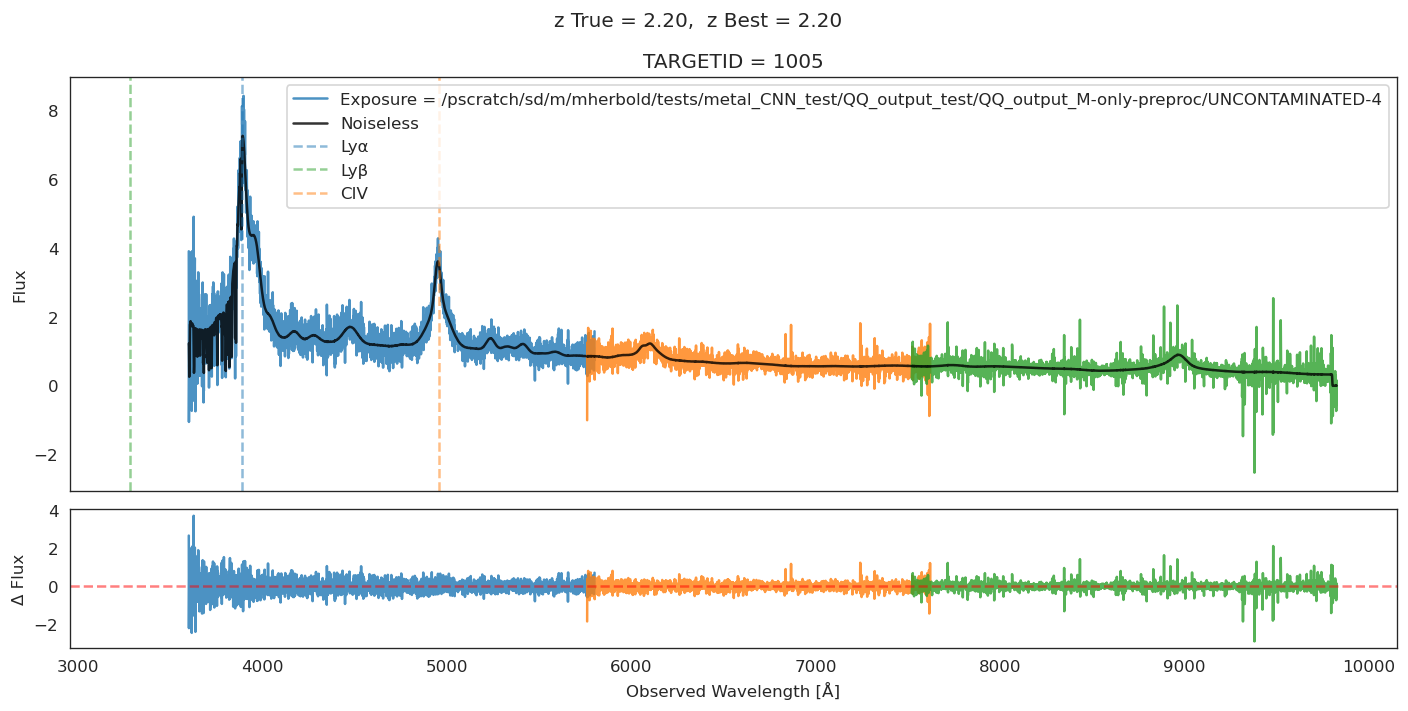

In [13]:
# Plot example QQ output quasar

# Choose quasar + exposure
# -------------------------------------------------

chosen_dump = dump[0]   # choose exposure file here

exposure = chosen_dump.split('/0.0-')[-1]

# -------------------------------------------------
# Read spectra
# -------------------------------------------------
spectra_exp = desispec.io.read_spectra(
    chosen_dump + '/spectra.fits'
)

# -------------------------------------------------
# Match TARGETID
# -------------------------------------------------
tid = truth[1]['TARGETID'][index]

targetids_exp  = spectra_exp.fibermap['TARGETID']
targetids_high = spectra_highexp.fibermap['TARGETID']

idx_exp  = np.where(targetids_exp  == tid)[0][0]
idx_high = np.where(targetids_high == tid)[0][0]

# -------------------------------------------------
# Create figure
# -------------------------------------------------
fig, (ax1, ax2) = plt.subplots(
    2, 1,
    figsize=(12,6),
    dpi=120,
    sharex=True,
    gridspec_kw={'height_ratios':[3,1]}
)

bands = ['b', 'r', 'z']

# -------------------------------------------------
# Plot spectra
# -------------------------------------------------
for band in bands:

    wave = spectra_exp.wave[band]

    flux_exp  = spectra_exp.flux[band][idx_exp]
    flux_high = spectra_highexp.flux[band][idx_high]

    # Exposure spectrum
    ax1.plot(
        wave,
        flux_exp,
        alpha=0.8,
        label=f'Exposure = {exposure}' if band=='b' else None
    )

    # Noiseless spectrum
    ax1.plot(
        wave,
        flux_high,
        color='k',
        alpha=0.8,
        label='Noiseless' if band=='b' else None
    )

    # Difference panel
    ax2.plot(
        wave,
        flux_exp - flux_high,
        alpha=0.8
    )

# -------------------------------------------------
# Spectral line markers
# -------------------------------------------------
z_obj = truth[1]['Z'][index]

lines = {
        'Lyα': (1215.67, 'tab:blue'),
        'Lyβ': (1025.722, 'tab:green'),
        'CIV': (1549.48, 'tab:orange')
    }
    
for name, (restwave, color) in lines.items():
    
    obswave = restwave * (1 + z_obj)
    
    ax1.axvline(
            obswave,
            color=color,
            ls='--',
            alpha=0.5,
            label=name
        )

# -------------------------------------------------
# Labels
# -------------------------------------------------
ax1.set_ylabel('Flux')
ax1.legend()

ax1.set_title(f'TARGETID = {tid}')

ax2.set_ylabel('Δ Flux')
ax2.set_xlabel('Observed Wavelength [Å]')

ax2.axhline(0, color='r', ls='--', alpha=0.5)

# Optional zooms
# ax1.set_xlim(3500,5000)
# ax1.set_xlim(4525,4725)

# -------------------------------------------------
# Redshift title
# -------------------------------------------------
redshift_true = truth[1]['z'][index]
redshift_shifted = data_zbest[1]['z'][index]

plt.suptitle(
    rf'z True = {redshift_true:.2f},  '
    rf'z Best = {redshift_shifted:.2f}'
)

plt.tight_layout()
plt.show()

## Metals

In [4]:
#list of all metals 

# metal_list = [
#     "MgI(2853)", "MgII(2804)", "MgII(2796)",
#     "FeII(2600)", "FeII(2587)", "MnII(2577)",
#     "FeII(2383)", "FeII(2374)", "FeII(2344)",
#     "AlIII(1863)", "AlIII(1855)", "AlII(1671)",
#     "FeII(1608)", "CIV(1551)", "CIV(1548)",
#     "SiII(1527)", "SiIV(1403)", "SiIV(1394)",
#     "CII(1335)", "SiII(1304)", "OI(1302)",
#     "SiII(1260)", "NV(1243)", "NV(1239)",
#     "SiIII(1207)", "NI(1200)", "SiII(1193)", "SiII(1190)",
#     "OI(1039)", "OVI(1038)", "OVI(1032)",
#     "LYB", "CIII(977)", "OI(989)", "SiII(990)",
#     "LY3", "LY4", "LY5",
# ]
# strength_list = [
#     "1e-4", "5e-4", "9e-4",          # MgI MgII(2804) MgII(2796)
#     "1e-4", "1e-4", "1e-4",          # FeII(2600) FeII(2587) MnII(2577)
#     "1e-4", "1e-4", "1e-4",          # FeII(2383) FeII(2374) FeII(2344)
#     "1e-4", "1e-4", "1e-4",          # AlIII(1863) AlIII(1855) AlII(1671)
#     "1e-4", "5.435e-4", "1.487e-3",  # FeII(1608) CIV(1551) CIV(1548)
#     "1e-4", "5e-4", "9e-4",          # SiII(1527) SiIV(1403) SiIV(1394)
#     "1e-4", "1e-4", "1e-4",          # CII(1335) SiII(1304) OI(1302)
#     "4.2504e-4", "5e-4", "5e-4",     # SiII(1260)* NV(1243) NV(1239)
#     "9.4595e-4", "1e-3", "6.354e-4", "4.496e-4",  # SiIII(1207)* NI(1200) SiII(1193)* SiII(1190)*
#     "1e-3", "3.382e-3", "5.358e-3",  # OI(1039) OVI(1038) OVI(1032)
#     "0.1901", "5e-3", "1e-3", "1e-3",# LYB CIII(977) OI(989) SiII(990)
#     "0.0697", "0.0335", "0.0187",    # LY3 LY4 LY5
# ]

# Wrap each metal name in single quotes so bash doesn't interpret parentheses
# metals  = " ".join(f"'{m}'" for m in metal_list)
# strengths = " ".join(strength_list)

In [5]:
# load desisim + quickquasars
import sys, os
sys.path.insert(0, "/pscratch/sd/m/mherbold/desisim/py")
env = os.environ.copy()
os.environ["DESIMODEL"] = "/global/homes/m/mherbold/.conda/envs/desi/lib/python3.10/site-packages/desimodel"

from desisim.scripts import quickquasars as qq

#######################################

contaminant = "METAL_TEST_MgI-TEMP-"

# metal_list = ["SiII(1304)"]
# strength_list = ["1e-4"]

metal_list = ['MgI(2853)']
strength_list = ["0.5"]

# exposures = ['1','2','3','4', '1e5']
exposures = ['4','1e5']

#######################################

base = Path(outdir)
for exp in exposures:
    outdir_metal = base / f"{contaminant}{exp}"
    outdir_metal.mkdir(parents=True, exist_ok=True)
    specfile = outdir_metal / "spectra.fits"
    
    if not os.path.exists(outdir +contaminant+exp):
        os.mkdir(outdir +contaminant+exp )
    specfile = outdir +contaminant+exp+'/spectra.fits'

    args = [
        "--exptime", str(float(exp)*1000),
        "-i", ifile,
        "-o", specfile,
        "--zmin", "2.2",
        "--zmax", "4.4",
        "--zbest",
        "--wmin", "3600.00",
        "--wmax", "9800.00",
        "--seed", "123",
        "--save-continuum",
        "--save-continuum-dwave", "2.0",
        "--overwrite",
        "--raw-mock", "ohio",
        "--metals", *metal_list,
        "--metal-strengths", *strength_list,
    ]

        # "--sigma_kms_fog", "150",
        # "--gamma_kms_zfit", "400",

    ret = qq.main(args)
    print("qq.main returned:", ret)

In [4]:
dump = []
# for exp in exposures:
    # dump.append( base / f"{contaminant}{exp}" +'0.0-'+exp)
dump.append('/pscratch/sd/m/mherbold/tests/metal_classification/QQ_output_test/QQ_output_M-only-preproc/METAL_TEST_MgI-TEMP-4')
dump.append('/pscratch/sd/m/mherbold/tests/metal_classification/QQ_output_test/QQ_output_M-only-preproc/METAL_TEST_MgI-TEMP-1e5')
path_highexp = dump[-1]
# path_highexp = dump[3]
del(dump[-1])
dump.sort()
print(path_highexp)

spec = fitsio.FITS(path_highexp+'/spectra.fits')
spec

/pscratch/sd/m/mherbold/tests/metal_CNN_test/QQ_output_test/QQ_output_M-only-preproc/METAL_TEST_MgI-TEMP-1e5



  file: /pscratch/sd/m/mherbold/tests/metal_CNN_test/QQ_output_test/QQ_output_M-only-preproc/METAL_TEST_MgI-TEMP-1e5/spectra.fits
  mode: READONLY
  extnum hdutype         hduname[v]
  0      IMAGE_HDU       
  1      BINARY_TBL      FIBERMAP
  2      IMAGE_HDU       B_WAVELENGTH
  3      IMAGE_HDU       B_FLUX
  4      IMAGE_HDU       B_IVAR
  5      IMAGE_HDU       B_MASK
  6      IMAGE_HDU       R_WAVELENGTH
  7      IMAGE_HDU       R_FLUX
  8      IMAGE_HDU       R_IVAR
  9      IMAGE_HDU       R_MASK
  10     IMAGE_HDU       Z_WAVELENGTH
  11     IMAGE_HDU       Z_FLUX
  12     IMAGE_HDU       Z_IVAR
  13     IMAGE_HDU       Z_MASK

In [5]:
truth = fitsio.FITS(path_highexp + '/truth-16-12.fits')
data_zbest = fitsio.FITS(path_highexp+'/zbest-16-12.fits')
spectra_highexp = desispec.io.read_spectra(path_highexp+'/spectra.fits')

INFO:spectra.py:453:read_spectra: iotime 0.060 sec to read spectra from:  spectra.fits at 2026-08-31T09:28:14.063689


In [7]:
index = 1

In [8]:
# Match TARGETID for True Continuum (HDU 3)
# -------------------------------------------------
tid = truth[1]['TARGETID'][index]
print(tid)

# Match TARGETID in HDU 3 (TRUE_CONT)
targetids_cont = truth[3]['TARGETID'][:]
print(targetids_cont)
idx_cont = np.where(targetids_cont == tid)

# Extract the true continuum flux array for this target
true_cont_flux = truth[3]['TRUE_CONT'][idx_cont]

# Define the standard DESI simulation continuum wavelength grid (1 Angstrom step)
wave_cont = np.arange(3600, 3600 + len(true_cont_flux), 1.0)
# Alternative if start/end are exact: np.linspace(3600, 6700, 3101)

1005
[1001 1005 1010 1016 1019 1020 1024 1025 1026 1027 1028 1030 1031 1032
 1035 1036 1037 1040 1045 1046 1049 1050 1051 1052 1054 1056 1057 1058
 1059 1061 1062 1063 1064 1065 1067 1068 1069 1070 1071 1072 1073 1074
 1075 1076 1077 1078 1080 1081 1083 1084 1085 1086 1087 1090 1091 1092
 1093 1097 1099 1101 1102 1104 1105 1106 1108 1109 1110 1111 1112 1117
 1121 1122 1123 1125 1126 1127 1128 1130 1131 1135 1136 1137 1140 1142
 1144 1147 1155 1157 1161 1162 1164 1167 1168 1170 1171 1173 1176 1180
 1181 1183 1186 1187 1190 1193 1194 1198 1200 1201 1202 1208 1209 1214
 1215 1217 1231 1239 1240 1244 1247 1251 1259 1272 1273 1279 1284 1286
 1291 1306 1312 1323 1330 1372 1374 1387 1435 1445 1481]


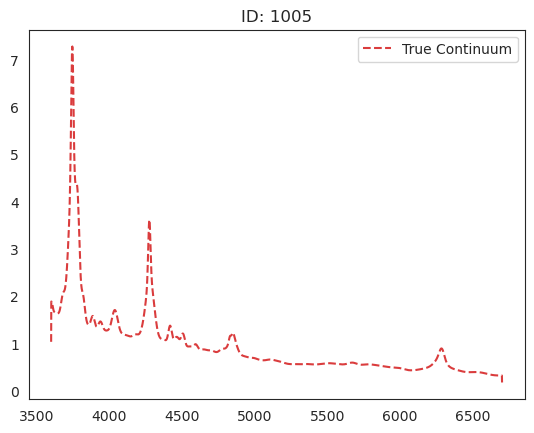

In [11]:
# check continuum
tid = truth[1]['TARGETID'][index]
# print(tid)

# Match TARGETID in HDU 3 (TRUE_CONT)
targetids_cont = truth[3]['TARGETID'][:]
# print(targetids_cont)
idx_cont = np.where(targetids_cont == tid)

# Extract the true continuum flux array for this target
true_cont_flux = truth[3]['TRUE_CONT'][idx_cont]

wave_cont = np.arange(3600, 3600 + true_cont_flux.size, 1.0)

plt.plot(
            wave_cont,
            true_cont_flux.flatten(),
            color='tab:red',
            ls='--',
            lw=1.5,
            alpha=0.9,
            label='True Continuum'
        )
plt.legend()
plt.title(f'ID: {tid}')
plt.show()

In [ ]:
index = 1

INFO:spectra.py:453:read_spectra: iotime 0.083 sec to read spectra from:  spectra.fits at 2026-08-31T09:29:22.235353


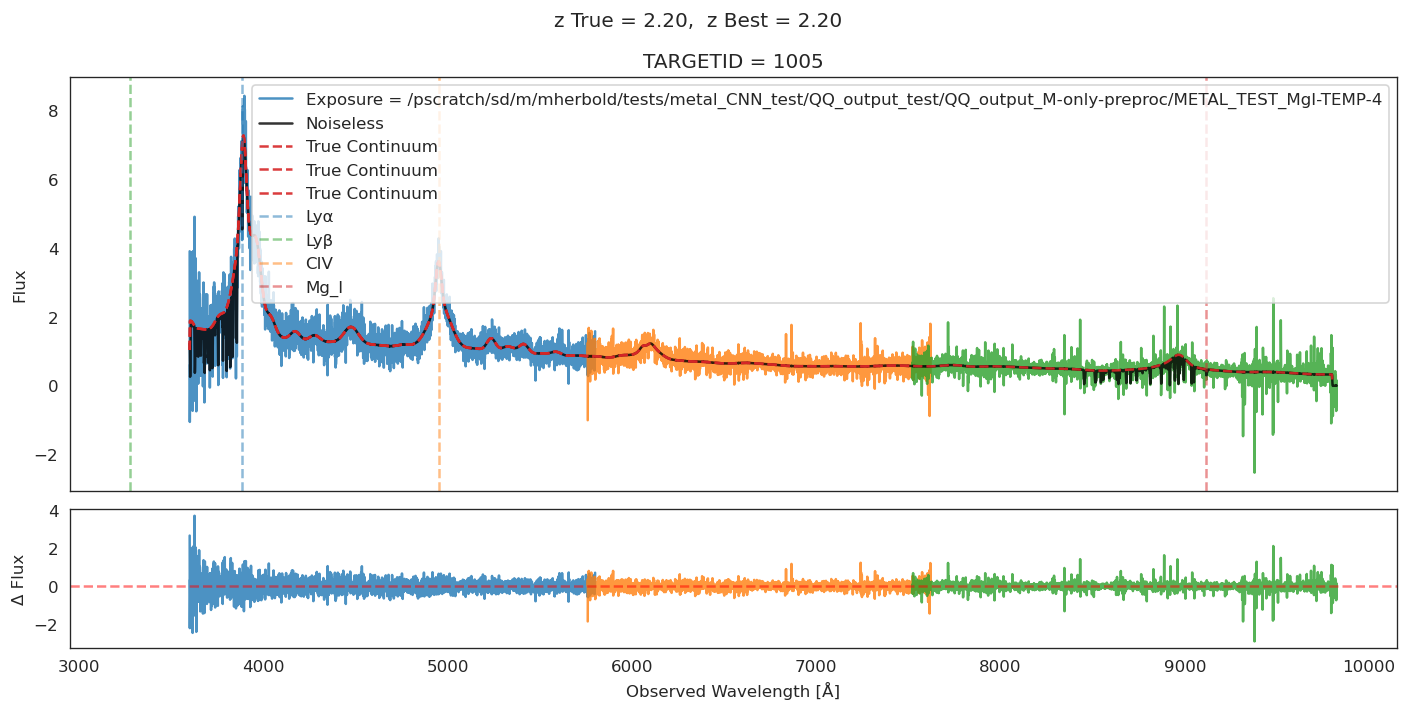

In [12]:
# Choose quasar + exposure
# -------------------------------------------------
# index = 1

chosen_dump = dump[0]   # choose exposure file here, here it is just exposure 4000s

exposure = chosen_dump.split('/0.0-')[-1]

# -------------------------------------------------
# Read spectra
# -------------------------------------------------
spectra_exp = desispec.io.read_spectra(
    chosen_dump + '/spectra.fits'
)

# -------------------------------------------------
# Match TARGETID for True Continuum (HDU 3)
# -------------------------------------------------
tid = truth[1]['TARGETID'][index]
# print(tid)

# Match TARGETID in HDU 3 (TRUE_CONT)
targetids_cont = truth[3]['TARGETID'][:]
# print(targetids_cont)
idx_cont = np.where(targetids_cont == tid)

# Extract the true continuum flux array for this target
true_cont_flux = truth[3]['TRUE_CONT'][idx_cont]

wave_cont = np.arange(3600, 3600 + true_cont_flux.size *2, 2.0)


# -------------------------------------------------
# Match TARGETID for Spectra
# -------------------------------------------------
targetids_exp  = spectra_exp.fibermap['TARGETID']
targetids_high = spectra_highexp.fibermap['TARGETID']

idx_exp  = np.where(targetids_exp  == tid)[0][0]
idx_high = np.where(targetids_high == tid)[0][0]

# -------------------------------------------------
# Create figure
# -------------------------------------------------
fig, (ax1, ax2) = plt.subplots(
    2, 1,
    figsize=(12,6),
    dpi=120,
    sharex=True,
    gridspec_kw={'height_ratios':[3,1]}
)

bands = ['b', 'r', 'z']

# -------------------------------------------------
# Plot spectra
# -------------------------------------------------
for band in bands:

    wave = spectra_exp.wave[band]

    flux_exp  = spectra_exp.flux[band][idx_exp]
    flux_high = spectra_highexp.flux[band][idx_high]

    # Exposure spectrum
    ax1.plot(
        wave,
        flux_exp,
        alpha=0.8,
        label=f'Exposure = {exposure}' if band=='b' else None
    )

    # Noiseless spectrum
    ax1.plot(
        wave,
        flux_high,
        color='k',
        alpha=0.8,
        label='Noiseless' if band=='b' else None
    )

    # 3. True Continuum
    # Option A: If TRUE_CONT shares the length of the band wave vector:
    # if len(true_cont_flux) == len(wave):
    ax1.plot(
            wave_cont,
            true_cont_flux.flatten(),
            color='tab:red',
            ls='--',
            lw=1.5,
            alpha=0.9,
            label='True Continuum'
        )

    # Difference panel
    ax2.plot(
        wave,
        flux_exp - flux_high,
        alpha=0.8
    )


# -------------------------------------------------
# Spectral line markers
# -------------------------------------------------
z_obj = truth[1]['Z'][index]

lines = {
        'Lyα': (1215.67, 'tab:blue'),
        'Lyβ': (1025.722, 'tab:green'),
        'CIV': (1549.48, 'tab:orange'),
    # contaminants
        # 'Si_II': (1304, 'tab:red'),
        'Mg_I': (2853, 'tab:red')
    }
    
for name, (restwave, color) in lines.items():
    
    obswave = restwave * (1 + z_obj)
    
    ax1.axvline(
            obswave,
            color=color,
            ls='--',
            alpha=0.5,
            label=name
        )

# -------------------------------------------------
# Labels
# -------------------------------------------------
ax1.set_ylabel('Flux')
ax1.legend()

ax1.set_title(f'TARGETID = {tid}')

ax2.set_ylabel('Δ Flux')
ax2.set_xlabel('Observed Wavelength [Å]')

ax2.axhline(0, color='r', ls='--', alpha=0.5)

# Optional zooms
# ax1.set_xlim(3500,5000)
# ax1.set_xlim(4525,4725)

# -------------------------------------------------
# Redshift title
# -------------------------------------------------
redshift_true = truth[1]['z'][index]
redshift_shifted = data_zbest[1]['z'][index]

plt.suptitle(
    rf'z True = {redshift_true:.2f},  '
    rf'z Best = {redshift_shifted:.2f}'
)

plt.tight_layout()
plt.show()